File found! Loading image from: C:\Users\sarah\source\repos\UCLan_ArtificialIntelligence\Assignment1\TestData\20251201_195833.jpg
Image successfully loaded. Shape: (2080, 2080)
Pixel Stats: Min=0, Max=251, Mean=134.83 (Expected 0-255 range)


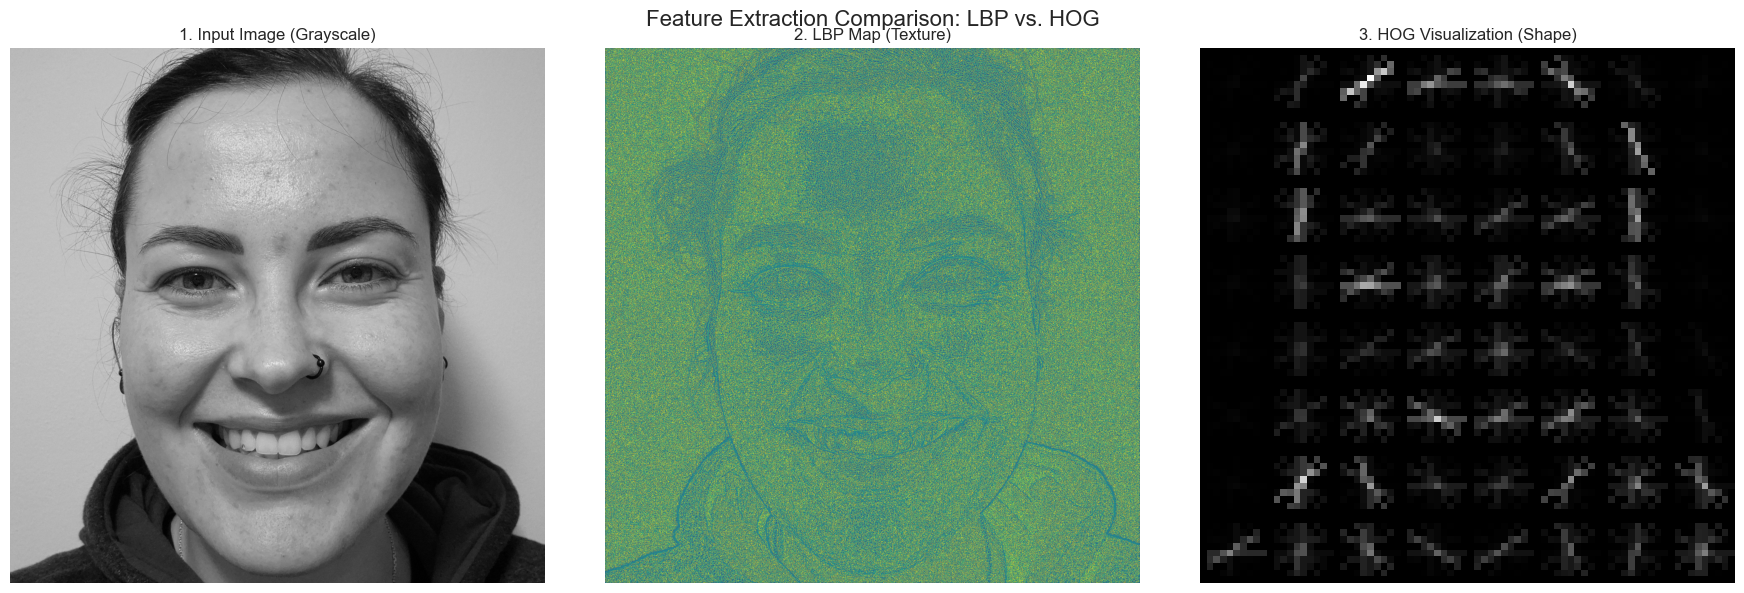

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage.feature import local_binary_pattern, hog
from skimage import exposure
from pathlib import Path

# --- Configuration ---

# >>> IMPORTANT: This absolute path must be exactly correct. <<<
LOCAL_IMAGE_PATH = Path("C:/Users/sarah/source/repos/UCLan_ArtificialIntelligence/Assignment1/TestData/20251201_195833.jpg")

# --- Feature Computation Functions ---

def compute_lbp(image):
    """Calculates the 2D LBP feature map for visualization."""
    # Standard LBP parameters: P=8 neighbors, R=1 radius
    P = 8
    R = 1
    # 'uniform' pattern is used for robust texture description
    # IMPORTANT: This returns the 2D map, not the histogram.
    lbp_map = local_binary_pattern(image, P, R, method='uniform')

    # You can calculate the histogram here, but we return the map for visualization
    # (lbp_hist, _) = np.histogram(lbp_map.ravel(), bins=np.arange(0, P + 3), range=(0, P + 2))
    # lbp_hist = lbp_hist.astype("float")
    # lbp_hist /= (lbp_hist.sum() + 1e-6)

    return lbp_map # RETURN THE 2D MAP

def compute_hog(image):
    """Calculates the HOG features and the visualization image."""

    # Resize is done here to ensure the HOG calculation is on a consistent scale
    # Ensure the image is a float array (skimage convention)
    resized_image = cv2.resize(image, (80, 80)).astype(np.float64) / 255.0

    # We set visualize=True to get the HOG visualization image
    features, hog_image = hog(
        resized_image, # Use the resized and normalized image
        orientations=9,
        pixels_per_cell=(10, 10),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        transform_sqrt=True,
        visualize=True
    )

    # Rescale the HOG visualization for better display contrast
    # NOTE: hog_image is already normalized by skimage, but we rescale for contrast
    hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 0.2))
    return hog_image_rescaled

def visualize_features(grayscale_image, lbp_map, hog_image):
    """Displays the original, LBP, and HOG images side-by-side."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # 1. Input Image (Grayscale)
    axes[0].imshow(grayscale_image, cmap='gray')
    axes[0].set_title(f'1. Input Image (Grayscale)')
    axes[0].axis('off')

    # 2. LBP Feature Map
    # The LBP map should have the same dimensions as the original image (before HOG resize).
    axes[1].imshow(lbp_map, cmap='viridis')
    axes[1].set_title(f'2. LBP Map (Texture)')
    axes[1].axis('off')

    # 3. HOG Visualization
    # HOG image is smaller due to cell/block processing and the resize operation in compute_hog
    axes[2].imshow(hog_image, cmap=plt.cm.gray)
    axes[2].set_title(f'3. HOG Visualization (Shape)')
    axes[2].axis('off')

    fig.suptitle('Feature Extraction Comparison: LBP vs. HOG', fontsize=16)
    plt.tight_layout()

    plt.savefig(f"FeatureExtractionComparison.png", dpi=300)

    plt.show()

# --- Execution ---

if __name__ == "__main__":
    local_path = LOCAL_IMAGE_PATH

    if not local_path.exists():
        print("----------------------------------------------------------------------")
        print(f"ERROR: File NOT FOUND at path: {local_path.resolve()}")
        print("ACTION: The script aborted. Check the absolute path above.")
        print("----------------------------------------------------------------------")
    else:
        print(f"File found! Loading image from: {local_path.resolve()}")
        try:
            # Load the image in grayscale using OpenCV, which handles the path string correctly
            # cv2.IMREAD_GRAYSCALE returns a numpy array with pixel values 0-255
            grayscale_image_8bit = cv2.imread(str(local_path), cv2.IMREAD_GRAYSCALE)

            if grayscale_image_8bit is None:
                raise IOError("OpenCV could not read the image file.")

            # --- CRITICAL DIAGNOSTIC STEP ---
            img_min = grayscale_image_8bit.min()
            img_max = grayscale_image_8bit.max()
            img_mean = grayscale_image_8bit.mean()

            print(f"Image successfully loaded. Shape: {grayscale_image_8bit.shape}")
            print(f"Pixel Stats: Min={img_min:.0f}, Max={img_max:.0f}, Mean={img_mean:.2f} (Expected 0-255 range)")

            # 1. Compute the features
            lbp_map = compute_lbp(grayscale_image_8bit)
            hog_image = compute_hog(grayscale_image_8bit)

            # 2. Display the results
            # Pass the 8-bit image to visualize_features since cv2.imshow expects 0-255 or 0-1 floats
            visualize_features(grayscale_image_8bit, lbp_map, hog_image)

        except Exception as e:
            print(f"An unexpected error occurred during image processing: {e}")